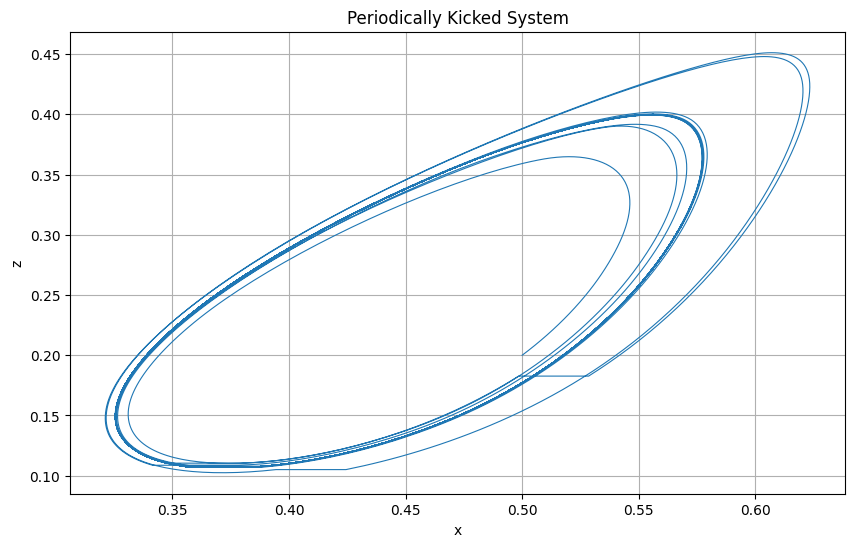

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================
# Parameters
# =========================

R = 3.0
p = 1.05
c = 0.2

# kick parameters
A = 0.03          # kick strength
Tkick = 20.0      # time between kicks

# initial condition
x0 = 0.5
z0 = 0.2

# total simulation time
t_final = 5000

# =========================
# System
# =========================

def sys(t, y, p, c, R):
    x, z = y

    dx = (
        p*(1 - z)*(1 - x)*(x**2)
        - p*(1 + z)*x*((1 - x)**2)
        + c*(1 - z)*(1 - x)
    )

    dz = R * x * z * (1 - z) - z

    return [dx, dz]

# =========================
# Periodically kicked integration
# =========================

times = []
xs = []
zs = []

y = np.array([x0, z0])

t0 = 0.0

while t0 < t_final:

    t1 = min(t0 + Tkick, t_final)

    t_eval = np.linspace(t0, t1, 200)

    sol = solve_ivp(
        sys,
        (t0, t1),
        y,
        args=(p, c, R),
        t_eval=t_eval,
        method='RK45'
    )

    # store trajectory
    times.extend(sol.t)
    xs.extend(sol.y[0])
    zs.extend(sol.y[1])

    # state just before kick
    y = sol.y[:, -1]

    # =========================
    # Apply kick
    # =========================
    y[0] += A

    # keep variables bounded
    y[0] = np.clip(y[0], 0, 1)
    y[1] = np.clip(y[1], 0, 1)

    t0 = t1

# convert to arrays
times = np.array(times)
xs = np.array(xs)
zs = np.array(zs)

# =========================
# Plot phase portrait
# =========================

plt.figure(figsize=(10, 6))
plt.plot(xs, zs, lw=0.8)

plt.xlabel('x')
plt.ylabel('z')
plt.title('Periodically Kicked System')
plt.grid()

plt.show()